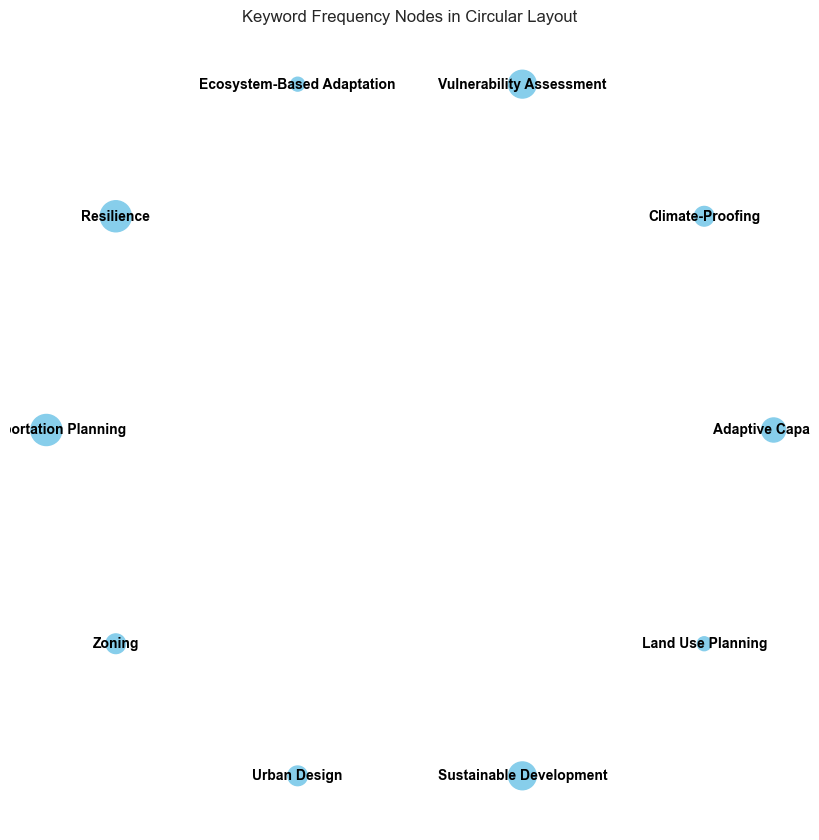

In [5]:
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np

# 关键词和它们的频率
keywords = [
    "Adaptive Capacity", "Climate-Proofing", "Vulnerability Assessment",
    "Ecosystem-Based Adaptation", "Resilience", "Transportation Planning",
    "Zoning", "Urban Design", "Sustainable Development", "Land Use Planning"
]

frequency = [
    3, 2, 4, 1, 5, 5, 2, 2, 4, 1
]

# 创建图形对象
G = nx.Graph()

# 向图中添加节点
for keyword, freq in zip(keywords, frequency):
    G.add_node(keyword, size=freq)

# 获取节点的数量
num_nodes = len(keywords)

# 定义圆形排列的位置
angles = np.linspace(0, 2 * np.pi, num_nodes, endpoint=False)
positions = {keywords[i]: (np.cos(angles[i]), np.sin(angles[i])) for i in range(num_nodes)}

# 绘制节点图
plt.figure(figsize=(8, 8))
node_sizes = [freq * 100 for freq in frequency]  # 根据频率调整节点大小
nx.draw(G, pos=positions, with_labels=True, node_size=node_sizes, node_color='skyblue', font_size=10, font_weight='bold', edge_color='gray')

# 设置图形的标题
plt.title('Keyword Frequency Nodes in Circular Layout')
plt.axis('equal')  # 保持圆形布局
plt.show()


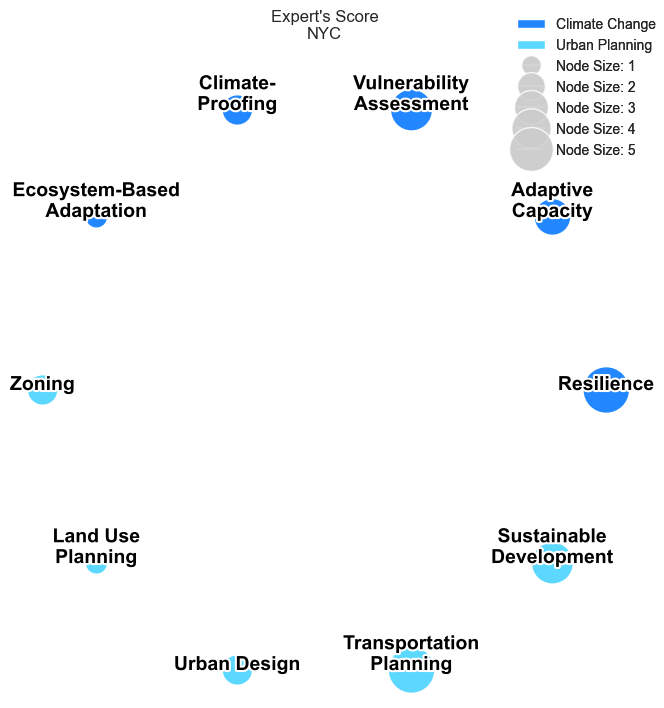

In [49]:
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import textwrap
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
import matplotlib.patheffects as path_effects

# 关键词和它们的频率
keywords = [
    "Adaptive Capacity", "Climate-Proofing", "Vulnerability Assessment",
    "Ecosystem-Based Adaptation", "Resilience", "Transportation Planning",
    "Zoning", "Urban Design", "Sustainable Development", "Land Use Planning"
]
frequency = [
    3, 2, 4, 1, 5, 5, 2, 2, 4, 1
]

# 定义自定义顺序列表
custom_order = ['resilience', 'adaptive capacity', 'vulnerability assessment', 'climate-proofing',
                'ecosystem-based adaptation', 'zoning', 'land use planning', 'urban design',
                'transportation planning', 'sustainable development']

# 转换关键词为小写字母，确保与自定义顺序一致
keywords_lower = [keyword.lower() for keyword in keywords]

# 使用自定义顺序重新排序关键词和频率
keywords = custom_order
frequency = [frequency[keywords_lower.index(keyword)] for keyword in custom_order]



# 创建图形对象
G = nx.Graph()

# 向图中添加节点
for keyword, freq in zip(keywords, frequency):
    G.add_node(keyword, size=freq)

# 获取节点的数量
num_nodes = len(keywords)

# 计算节点位置
radius = 0.5  # 设置一个较小的半径
angles = np.linspace(0, 2 * np.pi, num_nodes, endpoint=False)
positions = {keywords[i]: (radius * np.cos(angles[i]), radius * np.sin(angles[i])) for i in range(num_nodes)}

# 绘制节点图
plt.figure(figsize=(8, 8))
k = 200
sizes = frequency  # 使用频率作为节点大小的依据

# 绘制前五个固定节点（深蓝色，中心较大）
nx.draw_networkx_nodes(
    G,
    positions,
    nodelist=keywords[:5],  # 前五个节点
    node_color="#2388FF",
    node_size=[size * k for size in sizes[:5]],  # 计算前五个节点的大小
)

# 绘制剩余的固定节点（浅蓝色）
nx.draw_networkx_nodes(
    G,
    positions,
    nodelist=keywords[5:],  # 剩余节点
    node_color="#5CD8FF",
    node_size=[size * k for size in sizes[5:]],  # 计算剩余节点的大小
)

# 绘制边（不绘制连接，只有节点）
nx.draw_networkx_edges(
    G,
    positions,
    width=1.0,
    edge_color='#111111',
    alpha=0.7,
)

# 绘制标签并首字母大写，添加白色描边
for node, (x, y) in positions.items():
    weight = f"{frequency[keywords.index(node)]:.4f}" if frequency[keywords.index(node)] > 0 else "0"
    modified_node = f"{node}"  # Label the node
    wrapped_text = textwrap.fill(modified_node.title(), width=15)
    text = plt.text(
        x, y, wrapped_text, fontsize=14, fontweight='bold', ha='center', color='black'
    )
    text.set_path_effects([
        path_effects.Stroke(linewidth=3, foreground='white'),  # 添加白色描边
        path_effects.Normal()  # 恢复正常文字效果
    ])

# 设置图例
legend_elements = [
    Patch(facecolor='#2388FF', edgecolor='#ffffff', label='Climate Change'),  # 蓝色固定节点
    Patch(facecolor='#5CD8FF', edgecolor='#ffffff', label='Urban Planning'),   # 浅蓝色固定节点
]

# 添加图例节点大小部分
legend_node_sizes = [np.sqrt(size*k) for size in sizes]  # 计算半径
legend_node_weights = [node_weight for node_weight in sizes]

# 对节点权重和大小去重并排序，同时移除 NaN
unique_weights_sizes = sorted(
    {(w, s) for w, s in zip(legend_node_weights, legend_node_sizes) if not np.isnan(w) and not np.isnan(s)}
)
sorted_weights, sorted_sizes = zip(*unique_weights_sizes) if unique_weights_sizes else ([], [])

# 限制图例中最多五个节点，确保头尾都在
max_legend_items = 6

if len(sorted_weights) > max_legend_items:
    # 包含头尾节点
    first_weight, last_weight = sorted_weights[0], sorted_weights[-1]
    first_size, last_size = sorted_sizes[0], sorted_sizes[-1]

    # 从中间节点中等间距选取剩余的节点
    middle_weights = sorted_weights[1:-1]
    middle_sizes = sorted_sizes[1:-1]
    num_middle_items = max_legend_items - 2  # 除去头尾的数量

    if num_middle_items > 0:
        step = max(1, len(middle_weights) // num_middle_items)  # 计算步长
        sampled_indices = list(range(0, len(middle_weights), step))[:num_middle_items]
        middle_weights = [middle_weights[i] for i in sampled_indices]
        middle_sizes = [middle_sizes[i] for i in sampled_indices]
    else:
        middle_weights, middle_sizes = [], []

    # 合并头部、中间和尾部
    sorted_weights =  middle_weights + [last_weight]
    sorted_sizes =  middle_sizes + [last_size]

legend_elements.extend([
    Line2D([0], [0], marker='o', color='w', markersize=size, markerfacecolor='#CCCCCC', alpha=0.8, label=f"Node Size: {weight}")
    for size,weight in zip(sorted_sizes,sorted_weights)
])

# 绘制节点图例
node_legend = plt.legend(
    handles=legend_elements,  # 节点相关图例
    loc="upper right",
    bbox_to_anchor=(1.08, 1.15),
    fontsize=10,
    frameon=False,
    borderpad=1.5
)
plt.gca().add_artist(node_legend)


# 设置图标题
plt.title("Expert's Score\nNYC\n\n")

# 隐藏坐标轴
plt.axis('off')
plt.show()


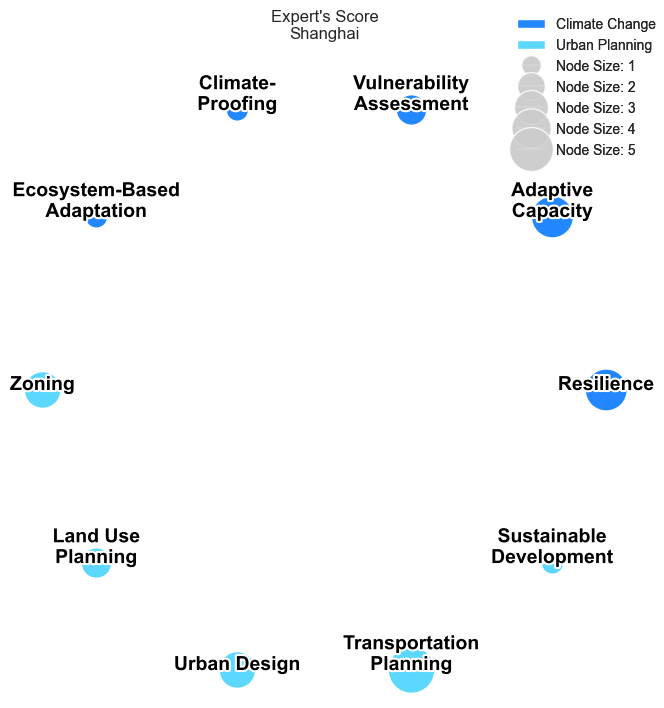

In [50]:
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import textwrap
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
import matplotlib.patheffects as path_effects

# 关键词和它们的频率
keywords = [
    "Adaptive Capacity", "Climate-Proofing", "Vulnerability Assessment",
    "Ecosystem-Based Adaptation", "Resilience", "Transportation Planning",
    "Zoning", "Urban Design", "Sustainable Development", "Land Use Planning"
]
frequency = [
    4,	1,	2,	1,	4,	5,	3,	3,	1,	2
]
# 定义自定义顺序列表
custom_order = ['resilience', 'adaptive capacity', 'vulnerability assessment', 'climate-proofing',
                'ecosystem-based adaptation', 'zoning', 'land use planning', 'urban design',
                'transportation planning', 'sustainable development']

# 转换关键词为小写字母，确保与自定义顺序一致
keywords_lower = [keyword.lower() for keyword in keywords]

# 使用自定义顺序重新排序关键词和频率
keywords = custom_order
frequency = [frequency[keywords_lower.index(keyword)] for keyword in custom_order]


# 创建图形对象
G = nx.Graph()

# 向图中添加节点
for keyword, freq in zip(keywords, frequency):
    G.add_node(keyword, size=freq)

# 获取节点的数量
num_nodes = len(keywords)

# 计算节点位置
radius = 0.5  # 设置一个较小的半径
angles = np.linspace(0, 2 * np.pi, num_nodes, endpoint=False)
positions = {keywords[i]: (radius * np.cos(angles[i]), radius * np.sin(angles[i])) for i in range(num_nodes)}

# 绘制节点图
plt.figure(figsize=(8, 8))
k = 200
sizes = frequency  # 使用频率作为节点大小的依据

# 绘制前五个固定节点（深蓝色，中心较大）
nx.draw_networkx_nodes(
    G,
    positions,
    nodelist=keywords[:5],  # 前五个节点
    node_color="#2388FF",
    node_size=[size * k for size in sizes[:5]],  # 计算前五个节点的大小
)

# 绘制剩余的固定节点（浅蓝色）
nx.draw_networkx_nodes(
    G,
    positions,
    nodelist=keywords[5:],  # 剩余节点
    node_color="#5CD8FF",
    node_size=[size * k for size in sizes[5:]],  # 计算剩余节点的大小
)

# 绘制边（不绘制连接，只有节点）
nx.draw_networkx_edges(
    G,
    positions,
    width=1.0,
    edge_color='#111111',
    alpha=0.7,
)

# 绘制标签并首字母大写，添加白色描边
for node, (x, y) in positions.items():
    weight = f"{frequency[keywords.index(node)]:.4f}" if frequency[keywords.index(node)] > 0 else "0"
    modified_node = f"{node}"  # Label the node
    wrapped_text = textwrap.fill(modified_node.title(), width=15)
    text = plt.text(
        x, y, wrapped_text, fontsize=14, fontweight='bold', ha='center', color='black'
    )
    text.set_path_effects([
        path_effects.Stroke(linewidth=3, foreground='white'),  # 添加白色描边
        path_effects.Normal()  # 恢复正常文字效果
    ])

# 设置图例
legend_elements = [
    Patch(facecolor='#2388FF', edgecolor='#ffffff', label='Climate Change'),  # 蓝色固定节点
    Patch(facecolor='#5CD8FF', edgecolor='#ffffff', label='Urban Planning'),   # 浅蓝色固定节点
]

# 添加图例节点大小部分
legend_node_sizes = [np.sqrt(size*k) for size in sizes]  # 计算半径
legend_node_weights = [node_weight for node_weight in sizes]

# 对节点权重和大小去重并排序，同时移除 NaN
unique_weights_sizes = sorted(
    {(w, s) for w, s in zip(legend_node_weights, legend_node_sizes) if not np.isnan(w) and not np.isnan(s)}
)
sorted_weights, sorted_sizes = zip(*unique_weights_sizes) if unique_weights_sizes else ([], [])

# 限制图例中最多五个节点，确保头尾都在
max_legend_items = 6

if len(sorted_weights) > max_legend_items:
    # 包含头尾节点
    first_weight, last_weight = sorted_weights[0], sorted_weights[-1]
    first_size, last_size = sorted_sizes[0], sorted_sizes[-1]

    # 从中间节点中等间距选取剩余的节点
    middle_weights = sorted_weights[1:-1]
    middle_sizes = sorted_sizes[1:-1]
    num_middle_items = max_legend_items - 2  # 除去头尾的数量

    if num_middle_items > 0:
        step = max(1, len(middle_weights) // num_middle_items)  # 计算步长
        sampled_indices = list(range(0, len(middle_weights), step))[:num_middle_items]
        middle_weights = [middle_weights[i] for i in sampled_indices]
        middle_sizes = [middle_sizes[i] for i in sampled_indices]
    else:
        middle_weights, middle_sizes = [], []

    # 合并头部、中间和尾部
    sorted_weights =  middle_weights + [last_weight]
    sorted_sizes =  middle_sizes + [last_size]

legend_elements.extend([
    Line2D([0], [0], marker='o', color='w', markersize=size, markerfacecolor='#CCCCCC', alpha=0.8, label=f"Node Size: {weight}")
    for size,weight in zip(sorted_sizes,sorted_weights)
])

# 绘制节点图例
node_legend = plt.legend(
    handles=legend_elements,  # 节点相关图例
    loc="upper right",
    bbox_to_anchor=(1.08, 1.15),
    fontsize=10,
    frameon=False,
    borderpad=1.5
)
plt.gca().add_artist(node_legend)


# 设置图标题
plt.title("Expert's Score\nShanghai\n\n")

# 隐藏坐标轴
plt.axis('off')
plt.show()
